# Load and Initial Exploration

In [ ]:
#  1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import re
import string

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [ ]:
#  2: Load the data
# For UCI SMS dataset
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
#  3: Clean up columns (for the SMS dataset)
# The UCI dataset has weird column names
df = df.iloc[:, :2]  # Keep only first two columns
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
#  4: Check for missing values
print("Missing values:")
print(df.isnull().sum())


Missing values:
label      0
message    0
dtype: int64



Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage spam: 13.41%


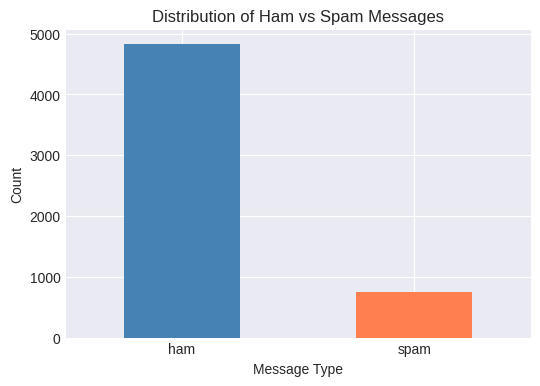

In [ ]:
#  5: Check class distribution
print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nPercentage spam: {df['label'].value_counts(normalize=True)['spam']*100:.2f}%")

# Visualize class distribution
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Feature Engineering 

In [ ]:
#  6: Create message length feature
df['message_length'] = df['message'].apply(len)

In [ ]:
#  7: Create word count feature
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

In [ ]:
#  8: Create punctuation count feature
df['punctuation_count'] = df['message'].apply(
    lambda x: sum(1 for char in str(x) if char in string.punctuation)
)

In [ ]:
#  9: Create uppercase count feature
df['uppercase_count'] = df['message'].apply(
    lambda x: sum(1 for char in str(x) if char.isupper())
)

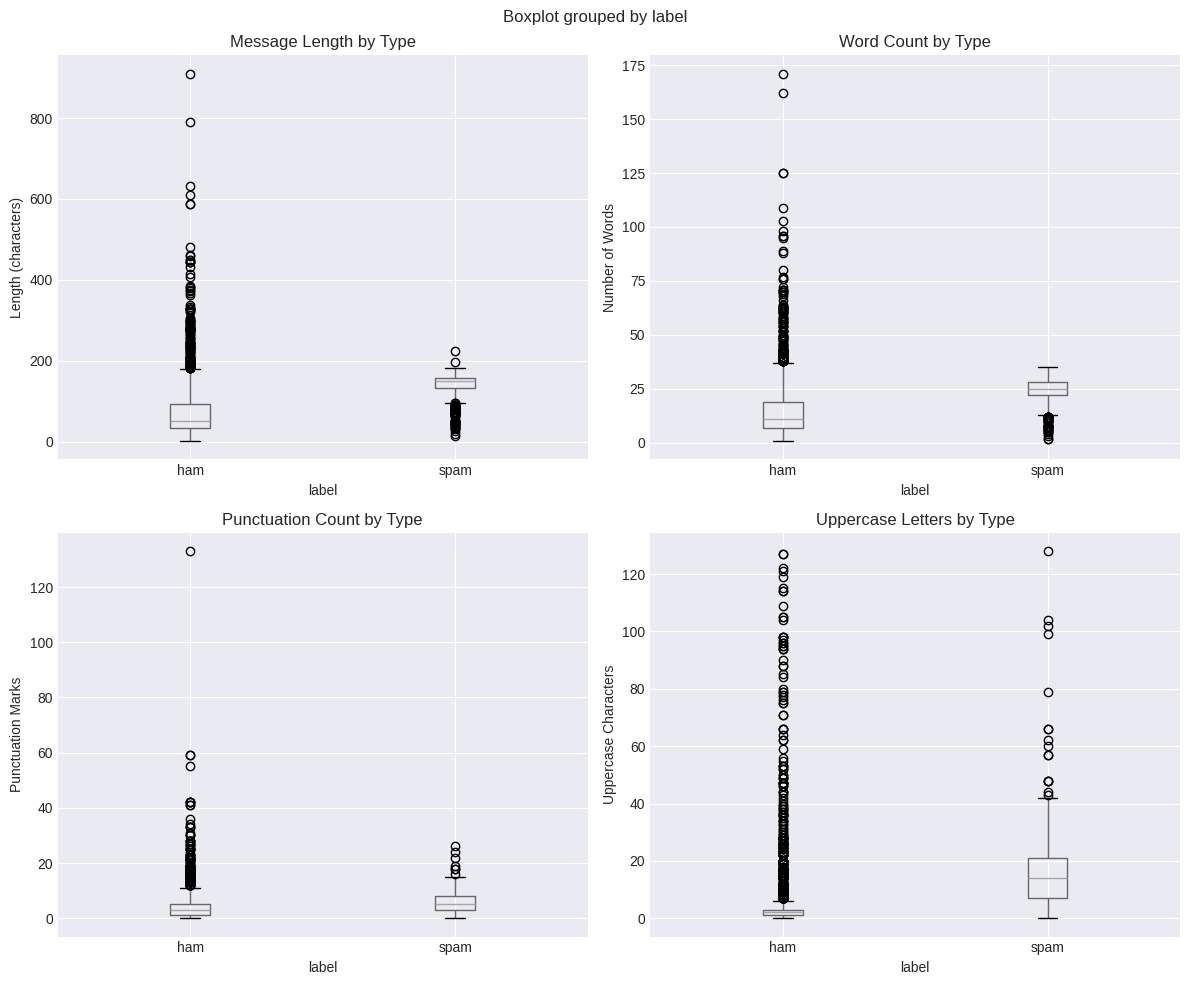

In [ ]:
#  10: Visualize features by class
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Message Length
df.boxplot(column='message_length', by='label', ax=axes[0,0])
axes[0,0].set_title('Message Length by Type')
axes[0,0].set_ylabel('Length (characters)')

# Word Count
df.boxplot(column='word_count', by='label', ax=axes[0,1])
axes[0,1].set_title('Word Count by Type')
axes[0,1].set_ylabel('Number of Words')

# Punctuation Count
df.boxplot(column='punctuation_count', by='label', ax=axes[1,0])
axes[1,0].set_title('Punctuation Count by Type')
axes[1,0].set_ylabel('Punctuation Marks')

# Uppercase Count
df.boxplot(column='uppercase_count', by='label', ax=axes[1,1])
axes[1,1].set_title('Uppercase Letters by Type')
axes[1,1].set_ylabel('Uppercase Characters')

plt.tight_layout()
plt.show()

# Text Preprocessing 

In [ ]:
#  11: Statistical summary by class
print("Statistical summary by message type:")
print(df.groupby('label')[['message_length', 'word_count', 'punctuation_count', 'uppercase_count']].describe())

Statistical summary by message type:
      message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0   
spam           747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0   

      word_count             ... punctuation_count        uppercase_count  \
           count       mean  ...               75%    max           count   
label                        ...                                            
ham       4825.0  14.200622  ...               5.0  133.0          4825.0   
spam       747.0  23.851406  ...               8.0   26.0           747.0   

                                                          
            mean        std  min  25%   50%   75%    max  
label                                                

# Text Preprocessing 

In [ ]:
#  12: Create text cleaning function
def clean_text(text):
    """Clean and preprocess text messages"""
    # Convert to string
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10,}\b', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [ ]:
#  13: Apply cleaning
print("Sample before cleaning:")
print(df['message'].iloc[0])

df['cleaned_message'] = df['message'].apply(clean_text)

print("\nSample after cleaning:")
print(df['cleaned_message'].iloc[0])

Sample before cleaning:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Sample after cleaning:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [ ]:
#  14: Check if cleaning helped
from sklearn.feature_extraction.text import CountVectorizer

# Compare vocabulary size before and after cleaning
cv_before = CountVectorizer(max_features=100)
cv_after = CountVectorizer(max_features=100)

cv_before.fit(df['message'].head(1000))
cv_after.fit(df['cleaned_message'].head(1000))

print(f"Vocabulary size before cleaning: {len(cv_before.vocabulary_)}")
print(f"Vocabulary size after cleaning: {len(cv_after.vocabulary_)}")

Vocabulary size before cleaning: 100
Vocabulary size after cleaning: 100


TF-IDF Vectorization 

In [ ]:
#  15: Prepare features and labels
X = df['cleaned_message']
y = df['label'].map({'ham': 0, 'spam': 1})  # Encode labels

In [ ]:
#  16: Split data (stratify to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training spam ratio: {y_train.mean():.3f}")
print(f"Test spam ratio: {y_test.mean():.3f}")

Training set size: 4457
Test set size: 1115
Training spam ratio: 0.134
Test spam ratio: 0.134


In [ ]:
#  17: Create and fit TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Limit vocabulary size
    ngram_range=(1, 2),     # Use unigrams and bigrams
    stop_words='english',    # Remove common English words
    min_df=2,               # Ignore terms that appear in less than 2 documents
    max_df=0.95             # Ignore terms that appear in >95% of documents
)

# Fit on training data, transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (4457, 5000)
TF-IDF matrix shape (test): (1115, 5000)


In [ ]:
#  18: Explore TF-IDF features
# Get the top features
feature_names = tfidf.get_feature_names_out()
print(f"\nTop 20 features by name: {feature_names[:20]}")

# Show feature importance by term frequency
tfidf_scores = X_train_tfidf.sum(axis=0).A1
top_indices = tfidf_scores.argsort()[-20:][::-1]

print("\nTop 20 features by frequency in training set:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {tfidf_scores[idx]:.0f} occurrences")


Top 20 features by name: ['020603' '020603 2nd' '0207' '0207 153' '050703' '07xxxxxxxxx'
 '07xxxxxxxxx won' '0800' '0800 169' '0800 1956669' '0800 542' '0808'
 '0808 145' '0825' '0845' '0870' '0870 national' '08700621170150p'
 '08700621170150p msg' '08701417012150p']

Top 20 features by frequency in training set:
  im: 78 occurrences
  ok: 74 occurrences
  just: 57 occurrences
  ill: 53 occurrences
  ltgt: 51 occurrences
  dont: 51 occurrences
  ur: 50 occurrences
  come: 50 occurrences
  like: 49 occurrences
  got: 49 occurrences
  know: 48 occurrences
  good: 44 occurrences
  time: 44 occurrences
  going: 42 occurrences
  want: 42 occurrences
  free: 40 occurrences
  sorry: 39 occurrences
  home: 39 occurrences
  lor: 37 occurrences
  later: 36 occurrences


# Model Development
Train Naive Bayes Model

In [ ]:
#  19: Initialize and train Multinomial Naive Bayes
model = MultinomialNB(alpha=0.5)  # alpha is Laplace smoothing parameter

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training complete!")
print(f"Training classes: {model.classes_}")
print(f"Prior probabilities: {model.class_log_prior_}")

Model training complete!
Training classes: [0 1]
Prior probabilities: [-0.14406781 -2.00864042]


In [ ]:
#  20: Make predictions
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)

# Get prediction probabilities
y_test_proba = model.predict_proba(X_test_tfidf)

In [ ]:
#  21: Evaluate performance
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba[:, 1])

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"AUC-ROC:           {auc:.4f}")
print("="*50)

MODEL PERFORMANCE METRICS
Training Accuracy: 0.9886
Test Accuracy:     0.9749
Precision:         0.9919
Recall:            0.8188
F1-Score:          0.8971
AUC-ROC:           0.9866


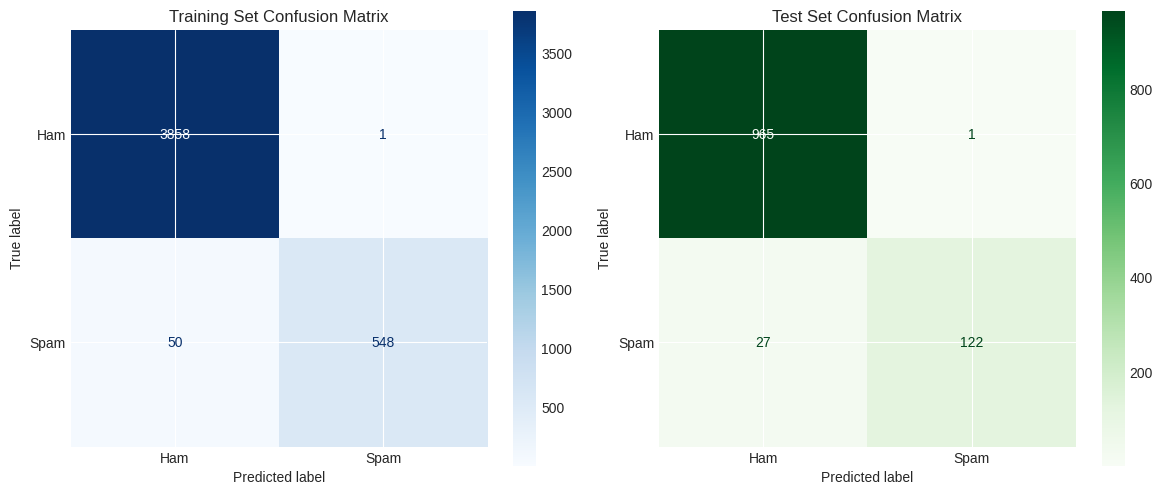

In [ ]:
#  22: Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model, X_train_tfidf, y_train,
    display_labels=['Ham', 'Spam'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title('Training Set Confusion Matrix')

# Test confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model, X_test_tfidf, y_test,
    display_labels=['Ham', 'Spam'],
    ax=axes[1], cmap='Greens'
)
axes[1].set_title('Test Set Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
#  23: Detailed Classification Report
print("\nDETAILED CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Ham', 'Spam']))


DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



# Error Analysis

In [ ]:
#  24: Find misclassified examples
misclassified_indices = np.where(y_test != y_test_pred)[0]
print(f"Number of misclassified examples: {len(misclassified_indices)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

Number of misclassified examples: 28
Misclassification rate: 2.51%


In [ ]:
#  25: Examine false positives (ham misclassified as spam)
false_positives = []
for idx in misclassified_indices:
    if y_test.iloc[idx] == 0 and y_test_pred[idx] == 1:
        false_positives.append({
            'message': X_test.iloc[idx],
            'true_label': 'Ham',
            'predicted_label': 'Spam',
            'confidence': y_test_proba[idx][1]
        })

print(f"\nFalse Positives (Ham → Spam): {len(false_positives)}")
print("\nExamples of False Positives:")
for i, fp in enumerate(false_positives[:5]):
    print(f"\n{i+1}. Message: {fp['message'][:100]}...")
    print(f"   Confidence: {fp['confidence']:.3f}")


False Positives (Ham → Spam): 1

Examples of False Positives:

1. Message: nokia phone is lovly...
   Confidence: 0.735


In [ ]:
#  26: Examine false negatives (spam misclassified as ham)
false_negatives = []
for idx in misclassified_indices:
    if y_test.iloc[idx] == 1 and y_test_pred[idx] == 0:
        false_negatives.append({
            'message': X_test.iloc[idx],
            'true_label': 'Spam',
            'predicted_label': 'Ham',
            'confidence': 1 - y_test_proba[idx][1]
        })

print(f"\nFalse Negatives (Spam → Ham): {len(false_negatives)}")
print("\nExamples of False Negatives (MISSED SPAM - More Dangerous!):")
for i, fn in enumerate(false_negatives[:5]):
    print(f"\n{i+1}. Message: {fn['message'][:100]}...")
    print(f"   Confidence (that it's ham): {fn['confidence']:.3f}")


False Negatives (Spam → Ham): 27

Examples of False Negatives (MISSED SPAM - More Dangerous!):

1. Message: you are now unsubscribed all services get tons of sexy babes or hunks straight to your phone go to n...
   Confidence (that it's ham): 0.597

2. Message: freemsg hey there darling its been 3 weeks now and no word back id like some fun you up for it still...
   Confidence (that it's ham): 0.653

3. Message: guess what somebody you know secretly fancies you wanna find out who it is give us a call on from la...
   Confidence (that it's ham): 0.637

4. Message: hi if ur lookin 4 saucy daytime fun wiv busty married woman am free all next week chat now 2 sort ti...
   Confidence (that it's ham): 0.885

5. Message: ringtoneking 84484...
   Confidence (that it's ham): 0.866


# Model Optimization

In [ ]:
#  27: Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

# Perform grid search
grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

Best parameters: {'alpha': 0.1, 'fit_prior': True}
Best cross-validation F1 score: 0.9427


In [ ]:
#  28: Train optimized model
best_model = MultinomialNB(**grid_search.best_params_)
best_model.fit(X_train_tfidf, y_train)

# Evaluate optimized model
y_test_pred_optimized = best_model.predict(X_test_tfidf)
test_accuracy_optimized = accuracy_score(y_test, y_test_pred_optimized)

print(f"\nOptimized Model Test Accuracy: {test_accuracy_optimized:.4f}")
print(f"Improvement: {(test_accuracy_optimized - test_accuracy)*100:.2f}%")


Optimized Model Test Accuracy: 0.9812
Improvement: 0.63%


In [ ]:
#  29: Try alternative algorithm (optional comparison)
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("\nLogistic Regression Performance:")
print(f"Test Accuracy: {lr_accuracy:.4f}")
print(f"F1 Score: {f1_score(y_test, lr_predictions):.4f}")

# Choose the better model (Naive Bayes is usually sufficient for spam detection)
final_model = best_model if test_accuracy_optimized >= lr_accuracy else lr_model
print(f"\nFinal model selected: {'Naive Bayes' if final_model is best_model else 'Logistic Regression'}")


Logistic Regression Performance:
Test Accuracy: 0.9686
F1 Score: 0.8679

Final model selected: Naive Bayes


# Save Model and Vectorizer 

In [ ]:
#  30: Save the model and vectorizer using pickle
import pickle

# Save model
with open('../models/spam_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print(" Model and vectorizer saved successfully!")

 Model and vectorizer saved successfully!


In [ ]:
#  31: Test loading and prediction
def test_saved_model():
    """Verify the saved model works correctly"""
    with open('../models/spam_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
        loaded_vectorizer = pickle.load(f)
    
    test_messages = [
        "Congratulations! You've won a free iPhone! Click here to claim",
        "Hey, are we still meeting for coffee tomorrow?",
        "URGENT: Your account has been compromised. Verify now",
        "Thanks for the update, I'll review it later"
    ]
    
    print("\nTesting saved model on sample messages:")
    print("-" * 60)
    for msg in test_messages:
        msg_cleaned = clean_text(msg)
        msg_vectorized = loaded_vectorizer.transform([msg_cleaned])
        prediction = loaded_model.predict(msg_vectorized)[0]
        probability = loaded_model.predict_proba(msg_vectorized)[0]
        
        label = "SPAM" if prediction == 1 else "HAM"
        confidence = probability[1] if prediction == 1 else probability[0]
        
        print(f"Message: {msg[:50]}...")
        print(f"Prediction: {label} (confidence: {confidence:.3f})\n")
    
    return loaded_model, loaded_vectorizer

final_model, vectorizer = test_saved_model()


Testing saved model on sample messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone! Click h...
Prediction: SPAM (confidence: 0.996)

Message: Hey, are we still meeting for coffee tomorrow?...
Prediction: HAM (confidence: 0.999)

Message: URGENT: Your account has been compromised. Verify ...
Prediction: SPAM (confidence: 0.954)

Message: Thanks for the update, I'll review it later...
Prediction: HAM (confidence: 0.985)

